<img style="float: center;" src='https://github.com/spacetelescope/jwst-pipeline-notebooks/raw/main/_static/stsci_header.png' alt="stsci_logo" width="900px"/> 

----
# NIRCam Grism Time Series Pipeline Notebook
----

**Authors**: Brian Brooks, Bryan Hilbert, Achrène Dyrek  based on the work by Nikolay Nikolov
<br>
**Last Update**: April 15, 2026
<br>
**Pipeline Version**: 2.0.0 (Build 12.3)

**Purpose**:<BR>
This notebook provides a framework for processing Near-Infrared
Camera (NIRCam) Grism Time Series data through all three James Webb Space Telescope
(JWST) [pipeline stages](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline/stages-of-jwst-data-processing). Data is assumed to be located in a folder structure
following the paths set up below. It should not be necessary to edit
any cells other than in the [Configuration](#1.-Configuration) section unless
modifying the standard pipeline processing options.

**Data**:<BR>
The example data for this notebook is a transit of WASP-39b, observed using grism time-series observing mode with the F322W2 filter. The data set belongs to the JWST Early Release Science [Program ID](https://www.stsci.edu/jwst/science-execution/program-information) 1366 (PI: Annabella Meech), observation 2, and includes 366 integrations of 12 groups each with the SUBGRISM256 subarray, covering a total of 10.45 hours. The data set consists of 4 segments of uncal files, each with a size of 1.25 GB. Example input data to use will be downloaded automatically unless disabled (i.e., to use local files instead).

**JWST pipeline version and CRDS context**:<br>
This notebook was written for the above-specified pipeline version and associated build context for this version of the JWST Calibration Pipeline. Information about this and other contexts can be found in the JWST Calibration Reference Data System (CRDS [server](https://jwst-crds.stsci.edu/)). If you use different pipeline versions, please refer to the table [here](https://jwst-crds.stsci.edu/display_build_contexts/) to determine what context to use. To learn more about the differences for the pipeline, read the relevant [documentation](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline/jwst-operations-pipeline-build-information#references).

Please note that pipeline software development is a continuous process, so results in some cases may be slightly different if a subsequent version is used. **For optimal results, users are strongly encouraged to reprocess their data using the most recent pipeline version and [associated CRDS context](https://jwst-crds.stsci.edu/display_build_contexts/), taking advantage of bug fixes and algorithm improvements.** Any [known issues](https://jwst-docs.stsci.edu/known-issues) for this build are noted in the notebook.<BR>

**Updates**:<BR>
This notebook is regularly updated as improvements are made to the
pipeline. Find the most up to date version of this notebook at:
https://github.com/spacetelescope/jwst-pipeline-notebooks/

**Recent Changes**:<br>
December 10, 2025: Updated notebook to be compatible with JWST pipeline version 1.20.2<br>
March 10, 2026: Updated to fix broken links and to be compatible with segemented uncal file changes<br>
April 15, 2026: Updated to be compatible with JWST pipeline version 2.0.0

## Table of Contents

1. [Configuration](#1.-Configuration)
2. [Package Imports](#2.-Package-Imports)
3. [Demo Mode Setup (ignore if not using demo data)](#3.-Demo-Mode-Setup-(ignore-if-not-using-demo-data)) 
4. [Directory Setup](#4.-Directory-Setup)
5. [Stage 1: `Detector1Pipeline` (`calwebb_detector1`)](#5.-Stage-1:-Detector1Pipeline(calwebb_detector1))
6. [Stage 2: `Spec2Pipeline` (`calwebb_spec2`)](#6.-Stage-2:-Spec2Pipeline-(calwebb_spec2))
7. [Stage 3: `Tso3Pipeline` (`calwebb_tso3`)](#7.-Stage-3:-Tso3Pipeline-(calwebb_tso3))
8. [Visualize the Data](#8.-Visualize-the-Data)

<hr style="border:1px solid gray"> </hr>

## 1. Configuration

### 1.1 Install dependencies
To make sure that the pipeline version is compatabile with this notebook and the required dependencies and taht packages are installed,
it is recommended that users create a new dedicated conda environment and install the provided
`requirements.txt` file before starting this notebook: <br>
```
conda create -n nircam_gts_pipeline python=3.13
conda activate nircam_gts_pipeline
pip install -r requirements.txt
```

<div class="alert alert-block alert-warning">
Note that <code>demo_mode</code> must be set appropriately below.
</div>

Set the basic parameters to use with this notebook. These parameters will affect
what data is used, where data is located (if already on disk), and
which pipeline modules will run on this data. The list of parameters are:

* `demo_mode`:
    * `True`: To run in demonstration mode. In this
mode this notebook will download example data from the Barbara A.
Mikulski Archive for Space Telescopes 
([MAST](https://mast.stsci.edu/search/ui/#/jwst)) and process it through 
the pipeline. This will all happen in a local directory unless modified in 
[Section 3](#3.-Demo-Mode-Setup-(ignore-if-not-using-demo-data)) below. 
    * `False`: If you want to process your own data that has already been downloaded and provide the location of the data.
* **Directories with data**:
    * `sci_dir`: Directory where science observation data are stored.
* **pipeline modules**:
    * `do_det1 = True` runs the Detector1 module on the selected data.
    * `do_spec2 = True` runs calwebb_spec2 module on the selected data.
    * `do_tso3 = True` runs calwebb_tso3 module on the selected data.
    * `do_viz = True` Creates plots to visualize calwebb_tso3 results.

In [1]:
# Basic import necessary for configuration
import os

In [2]:
# Set parameters for demo_mode, data directory, and processing steps

# -----------------------------Demo Mode---------------------------------
demo_mode = True

if demo_mode:
    print('Running in demonstration mode using online example data!')

# --------------------------User Mode Directories------------------------
# If demo_mode = False, look for user data in these paths
if not demo_mode:
    # Set directory paths for processing specific data; these will need
    # to be changed to the user's local directory setup (paths below are given as
    # examples).
    basedir = os.path.join(os.getcwd(), '')

    # Point to where the observation data are stored.
    # Assumes uncalibrated data in sci_dir/uncal/ with results stored in stage1, stage2, stage3 directories.
    sci_dir = os.path.join(basedir, 'PID01366/Obs002/')

# --------------------------Set Processing Steps--------------------------
# Individual pipeline stages can be turned on/off here.  Note that a later
# stage won't be able to run unless data products have already been
# produced from the prior stage.

# Pipeline processing
do_det1 = True  # calwebb_detector1
do_spec2 = True  # calwebb_spec2
do_tso3 = True  # calwebb_tso3
do_viz = True  # Visualize calwebb_tso3 results

Running in demonstration mode using online example data!


### 1.2 Set CRDS context and server
Before importing <code>CRDS</code> and <code>JWST</code> modules, we need
to configure our environment. This includes defining a CRDS cache
directory in which to keep the reference files that will be used by the
calibration pipeline.

If the local CRDS cache directory has not been set, it will automatically be created in the home directory.

The [Build Context Table](https://jwst-crds.stsci.edu/display_build_contexts/) lists the CRDS context file that is associated with each pipeline release version.

In [3]:
# ------------------------Set CRDS context and paths----------------------

# Each version of the calibration pipeline is associated with a specific CRDS
# context file. The pipeline will select the appropriate context file behind
# the scenes while running. However, if you wish to override the default context
# file and run the pipeline with a different context, you can set that using
# the CRDS_CONTEXT environment variable. Here we show how this is done,
# although we leave the line commented out in order to use the default context.
# If you wish to specify a different context, uncomment the line below.
#%env CRDS_CONTEXT jwst_1535.pmap
#os.environ['CRDS_CONTEXT'] = 'jwst_1535.pmap'  # CRDS context for pipeline version 2.0.0

# Check whether the local CRDS cache directory has been set.
# If not, set it to the user home directory
if (os.getenv('CRDS_PATH') is None):
    os.environ['CRDS_PATH'] = os.path.join(os.path.expanduser('~'), 'crds')

# Check whether the CRDS server URL has been set.  If not, set it.
if (os.getenv('CRDS_SERVER_URL') is None):
    os.environ['CRDS_SERVER_URL'] = 'https://jwst-crds.stsci.edu'

# Echo CRDS path in use
print(f"CRDS local filepath: {os.environ['CRDS_PATH']}")
print(f"CRDS file server: {os.environ['CRDS_SERVER_URL']}")
if os.getenv('CRDS_CONTEXT'):
    print(f"CRDS CONTEXT: {os.environ['CRDS_CONTEXT']}")

CRDS local filepath: /home/runner/crds
CRDS file server: https://jwst-crds.stsci.edu


<hr style="border:1px solid gray"> </hr>

## 2. Package Imports

In [4]:
# Use the entire available screen width for this notebook
from IPython.display import display, HTML, JSON
display(HTML("<style>.container { width:95% !important; }</style>"))

In [5]:
# Basic system utilities for interacting with files
# ----------------------General Imports------------------------------------
import glob
import time
import json
from pathlib import Path

# Numpy for doing calculations
import numpy as np

# To display full output of cell, not just the last result
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# -----------------------Astropy Imports-----------------------------------
# Astropy utilities for opening FITS and downloading demo files, etc.
from astropy.io import fits
from astroquery.mast import Observations
from astropy.table import Table

# ----------------------Plotting Imports---------------------
import matplotlib.pyplot as plt
from astropy.stats import sigma_clip
from astropy.visualization import ImageNormalize
from astropy.visualization import AsinhStretch
import pandas as pd

<div class="alert alert-block alert-info">

Installation instructions for the JWST pipeline found here: [JDox](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline-overview) • 
[ReadtheDocs](https://jwst-pipeline.readthedocs.io) • 
[Github](https://github.com/spacetelescope/jwst)

</div> 

In [6]:
# --------------JWST Calibration Pipeline Imports---------------------------
# Import the base JWST and calibration reference data packages
import jwst
import crds

# JWST pipelines (each encompassing many steps)
from jwst.pipeline import Detector1Pipeline
from jwst.pipeline import Spec2Pipeline
from jwst.pipeline import Tso3Pipeline

# JWST pipeline utilities
from jwst import datamodels
from jwst.associations import asn_from_list as afl  # Tools for creating association files
from jwst.associations.lib.rules_level3_base import DMS_Level3_Base  # Definition of a Lvl3 association file

# Print out pipeline version and CRDS context that will be used
print("JWST Calibration Pipeline Version = {}".format(jwst.__version__))
print("Using CRDS Context = {}".format(crds.get_context_name('jwst')))

JWST Calibration Pipeline Version = 2.0.0


CRDS - INFO -  Calibration SW Found: jwst 2.0.0 (/home/runner/micromamba/envs/ci-env/lib/python3.11/site-packages/jwst-2.0.0.dist-info)


Using CRDS Context = jwst_1535.pmap


In [7]:
# Start a timer to keep track of runtime
time0 = time.perf_counter()

<hr style="border:1px solid gray"> </hr>

## 3. Demo Mode Setup (ignore if not using demo data)

------------------
If running in demonstration mode, set up the program information to
retrieve the uncalibrated data automatically from MAST using
[astroquery](https://astroquery.readthedocs.io/en/latest/mast/mast.html).
MAST allows for flexibility of searching by the proposal ID and the
observation ID instead of just filenames.<br>

The [JWST file naming conventions page](https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/file_naming.html)
provides information about the JWST file naming conventions and can help to decode filenames output from various pipelines and steps.

### 3.1 Create directory strucutre

In [8]:
# Set up the program information and paths for demo program
if demo_mode:
    print('Running in demonstration mode and will download example data from MAST!')
    program = "01366"
    sci_obs = "002"

    # NOTE:
    # The data in this notebook is public and does not require a token.
    # For other data sets, you may need to provide a token.
    # Observations.login(token=None)

    data_dir = os.path.join('.', 'nrc_tso_demo_data')
    download_dir = os.path.join(data_dir, program)
    sci_dir = os.path.join(download_dir, 'Obs' + sci_obs)
    uncal_dir = os.path.join(sci_dir, 'uncal')

    # Ensure filepaths for input data exist
    if not os.path.exists(uncal_dir):
        os.makedirs(uncal_dir, exist_ok=True)

    # Create directory if it does not exist
    if not os.path.isdir(data_dir):
        os.mkdir(data_dir, exist_ok=True)

Running in demonstration mode and will download example data from MAST!


### 3.2 Query MAST for data
Compile tables of files from MAST associated with the science (SCI) observations.

In [9]:
# Obtain a list of observation IDs for the specified demo program
if demo_mode:
    sci_obs_id_table = Observations.query_criteria(instrument_name=["NIRCAM/*"],
                                                   provenance_name=["CALJWST"],  # Executed observations
                                                   obs_id=['jw' + program + '-o' + sci_obs + '*']
                                                   )

In [10]:
if demo_mode:
    sci_obs_id_table

intentType,obs_collection,provenance_name,instrument_name,project,filters,wave_region,target_name,target_classification,obs_id,s_ra,s_dec,dataproduct_type,proposal_pi,calib_level,t_min,t_max,t_exptime,wavelength_region,em_min,em_max,obs_title,t_obs_release,proposal_id,proposal_type,sequence_number,s_region,jpegURL,dataURL,dataRights,mtFlag,srcDen,obsid,objID,wave_min,wave_max
str7,str4,str7,str12,str4,str13,str8,str7,str23,str50,float64,float64,str10,str16,int64,float64,float64,float64,str8,float64,float64,str64,float64,str4,str3,int64,str132,str1,str81,str6,bool,float64,str8,str10,float64,float64
science,JWST,CALJWST,NIRCAM/GRISM,JWST,F322W2;GRISMR,INFRARED,WASP-39,Star; Exoplanet Systems,jw01366-o002_t001_nircam_f322w2-grismr-subgrism256,217.32661050118682,-3.44449932372744,timeseries,"Meech, Annabella",3,59782.783412233795,59783.15175280093,29080.424,INFRARED,2430.0,4013.0000000000005,The Transiting Exoplanet Community Early Release Science Program,59783.35921298,1366,ERS,--,POLYGON 217.35463336 -3.44487113 217.31827043 -3.44512151 217.31832056 -3.44053818 217.35454974 -3.44034058 217.35463336 -3.44487113,--,mast:JWST/product/jw01366-o002_t001_nircam_f322w2-grismr-subgrism256_x1dints.fits,PUBLIC,False,nan,87682152,1083724673,2430.0,4013.0000000000005


<div class="alert alert-info">

[NIRCam Grism Time Series](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-observing-modes/nircam-time-series-observations/nircam-grism-time-series) mode allows simultaneous imaging with the weak lens (WL), or spectroscopy via the Dispersed Hartmann Sensor (DHS) in the short-wavelength (SW) channel, along with spectroscopy using the grism in the long-wavelength (LW) channel. The process of [Target Acquisition](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-operations/nircam-target-acquisition) (TA) also produces an imaging mode file using the TA subarray. In this notebook, we will focus only on the LW grism data which uses the [`Spec2Pipeline`](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_spec2.html). Further, <b>the example data in this notebook are from a program where the LW data were obtained in concert with weak lens data (imaging Time Series mode) in the SW channel. Note that LW Grism Time Series data obtained in concert with DHS observations in the SW channel have a different file format, and will be covered in a separate pipeline notebook.</b> SW time series data, including observations using the weak lens and the DHS, will also be covered in separate notebooks.

Since Time Series Observations often result in a large amount of data, the data is stored as [segemented products](https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/file_naming.html#segmented-products). To mitigate download crashes and processing issues, it is recommended to download and work with one NIRCam channel (short or long) at a time. 

</div>

In [11]:
# Turn the list of visits into a list of uncalibrated data files
if demo_mode:
    # Define types of files to select
    file_dict = {'uncal': {'product_type': 'SCIENCE',
                           'productSubGroupDescription': 'UNCAL',
                           'calib_level': [1]}}

    # Science files
    sci_files_to_download = []
    # Loop over visits identifying uncalibrated files that are associated with them

    for exposure in (sci_obs_id_table):
        products = Observations.get_product_list(exposure)
        for filetype, query_dict in file_dict.items():
            filtered_products = Observations.filter_products(products, productType=query_dict['product_type'],
                                                             productSubGroupDescription=query_dict['productSubGroupDescription'],
                                                             calib_level=query_dict['calib_level'])
            sci_files_to_download.extend(filtered_products['dataURI'])

    # To limit data volume, we will only download LW Grism data
    # lw detector
    sci_files_to_download_lw = np.unique([i for i in sci_files_to_download if 'nrcalong' in i])

    # sw detectors
    #detectors = ['nrca1', 'nrca3']
    #sci_files_to_download_sw = np.unique([i for i in sci_files_to_download if any(d in i for d in detectors)])

    # All data
    #sci_files_to_download = sorted(sci_files_to_download)

    print(f"Long-wave science files selected for downloading: {len(sci_files_to_download_lw)}")
    #print(f"Short-wave science files selected for downloading: {len(sci_files_to_download_sw)}")
    #print(f"Science files selected for downloading: {len(sci_files_to_download)}")

Long-wave science files selected for downloading: 5


### 3.3 Download the data
<div class="alert alert-block alert-warning">
    
**Warning:** If this notebook is halted during this step, the downloaded file may be incomplete and corrupted, and cause crashes later on!
</div>

In [12]:
if demo_mode:
    for filename in sci_files_to_download_lw:
        obs_manifest = Observations.download_file(filename, local_path=os.path.join(uncal_dir, Path(filename).name))

# Example that would download the SW files
#if demo_mode:
#    for filename in sci_files_to_download_sw:
#        obs_manifest = Observations.download_file(filename, local_path=os.path.join(uncal_dir, Path(filename).name))

# Example that would download both LW and SW files
#if demo_mode:
#    for filename in sci_files_to_download:
#        obs_manifest = Observations.download_file(filename, local_path=os.path.join(uncal_dir, Path(filename).name))

 [Done]


 [Done]


 [Done]


 [Done]


 [Done]


<hr style="border:1px solid gray"> </hr>

## 4. Directory Setup

Set up detailed paths to input/output stages here. When running this notebook outside of demo mode, the uncalibrated pipeline input files must be placed into the appropriate directories before proceeding to the JWST pipeline processing.

In [13]:
# Define output subdirectories to keep science data products organized
uncal_dir = os.path.join(sci_dir, 'uncal')     # Uncalibrated pipeline inputs should be here
det1_dir = os.path.join(sci_dir, 'stage1')     # calwebb_detector1 pipeline outputs will go here
spec2_dir = os.path.join(sci_dir, 'stage2')    # calwebb_spec2 pipeline outputs will go here
tso3_dir = os.path.join(sci_dir, 'stage3')     # calwebb_tso3 pipeline outputs will go here

# Create desired output directories, if needed
os.makedirs(det1_dir, exist_ok=True)
os.makedirs(spec2_dir, exist_ok=True)
os.makedirs(tso3_dir, exist_ok=True)

In [14]:
# List uncal files
uncal_files = sorted(glob.glob(os.path.join(uncal_dir, '*_uncal.fits')))

# Separate TA file
lw_ta_file = []
sw_uncal_files = []
lw_uncal_files = []

for unc_fi in uncal_files:
    fi = datamodels.open(unc_fi)

    # SW files are not downloaded by default, but we leave
    # SW-related lines here for cases where the user provides
    # their own data.
    if fi.meta.exposure.type == 'NRC_TSIMAGE':
        sw_uncal_files.append(unc_fi)

    if fi.meta.exposure.type == 'NRC_TSGRISM':
        lw_uncal_files.append(unc_fi)

    if fi.meta.exposure.type == 'NRC_TACQ':
        lw_ta_file.append(unc_fi)

colnames = ('Instrument', 'Filter', 'Pupil', 'Number of Integrations', 'Number of Groups',
            'Readout pattern', 'Exposure Type')
dtypes = ('S7', 'S10', 'S10', 'i4', 'i4', 'S15', 'S11')
meta_check = Table(names=(colnames), dtype=dtypes)

# Open example files and get metadata for display
for sw_f in sw_uncal_files:
    sw_examine = datamodels.open(sw_f)
    sw_row = [sw_examine.meta.instrument.name, sw_examine.meta.instrument.filter,
              sw_examine.meta.instrument.pupil, sw_examine.meta.exposure.nints,
              sw_examine.meta.exposure.ngroups, sw_examine.meta.exposure.readpatt, sw_examine.meta.exposure.type]
    meta_check.add_row(sw_row)

for lw_f in lw_uncal_files:
    lw_examine = datamodels.open(lw_f)
    lw_row = [lw_examine.meta.instrument.name, lw_examine.meta.instrument.filter,
              lw_examine.meta.instrument.pupil, lw_examine.meta.exposure.nints,
              lw_examine.meta.exposure.ngroups, lw_examine.meta.exposure.readpatt, lw_examine.meta.exposure.type]
    meta_check.add_row(lw_row)

if len(lw_ta_file) == 1:
    ta_examine = datamodels.open(lw_ta_file[0])
    TA_row = [ta_examine.meta.instrument.name, ta_examine.meta.instrument.filter,
              ta_examine.meta.instrument.pupil, ta_examine.meta.exposure.nints,
              ta_examine.meta.exposure.ngroups, ta_examine.meta.exposure.readpatt, ta_examine.meta.exposure.type]
    meta_check.add_row(TA_row)

# Print out exposure info
meta_check

Instrument,Filter,Pupil,Number of Integrations,Number of Groups,Readout pattern,Exposure Type
bytes7,bytes10,bytes10,int32,int32,bytes15,bytes11
NIRCAM,F322W2,GRISMR,366,12,SHALLOW4,NRC_TSGRISM
NIRCAM,F322W2,GRISMR,366,12,SHALLOW4,NRC_TSGRISM
NIRCAM,F322W2,GRISMR,366,12,SHALLOW4,NRC_TSGRISM
NIRCAM,F322W2,GRISMR,366,12,SHALLOW4,NRC_TSGRISM
NIRCAM,F335M,CLEAR,1,17,RAPID,NRC_TACQ


In [15]:
# Print out the time benchmark
time_det1 = time.perf_counter()
print(f"Runtime so far: {time_det1 - time0:0.0f} seconds")

Runtime so far: 58 seconds


<hr style="border:1px solid gray"> </hr>

## 5. Stage 1: `Detector1Pipeline`(`calwebb_detector1`)

In this section, we process the data through the `calwebb_detector1` pipeline to create Stage 1 [data products](https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/science_products.html#countrate-data-rate-and-rateints).

* **Input**: Raw exposure (`_uncal.fits`) containing original data from all detector readouts (ncols x nrows x ngroups x nintegrations).
* **Output**: Uncalibrated countrate (slope) image in units of DN/s:
    * `_rate.fits`: A single countrate image averaged over multiple integrations (if available).
    * `_rateints.fits`: Countrate images for each integration, saved in multiple extensions.

The `Detector1Pipeline` applies basic detector-level corrections on a group-by-group basis, followed by ramp fitting for all exposure types, commonly referred to as "ramps-to-slopes" processing. 

---

### 5.1 Configure `Detector1Pipeline`

Below, we set up a dictionary that defines how the `Detector1Pipeline` should be configured. 

For more information about each step and a full list of step arguments, please refer to the official documentation: [JDox](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline-overview/stages-of-jwst-data-processing/calwebb_detector1) •
[ReadtheDocs](https://jwst-pipeline.readthedocs.io/en/stable/jwst/pipeline/calwebb_detector1.html)


<div class="alert alert-info">
    
By default, all steps in the `Detector1` stage of the pipeline are run for
NIRCam except the `ipc`, `persistence`, and `charge_migration` steps. 
    
</div>

In [16]:
# Set up a dictionary to define how the Detector1 pipeline should be configured

# Boilerplate dictionary setup
det1dict = {}
det1dict['group_scale'], det1dict['dq_init'], det1dict['saturation'] = {}, {}, {}
det1dict['ipc'], det1dict['superbias'], det1dict['refpix'] = {}, {}, {}
det1dict['linearity'], det1dict['persistence'], det1dict['dark_current'], = {}, {}, {}
det1dict['charge_migration'], det1dict['jump'], det1dict['clean_flicker_noise'], det1dict['ramp_fit'] = {}, {}, {}, {}

# Overrides for various reference files
# Files should be in the base local directory or provide full path
#det1dict['dq_init']['override_mask'] = 'myfile.fits' # Bad pixel mask
#det1dict['saturation']['override_saturation'] = 'myfile.fits'  # Saturation
#det1dict['linearity']['override_linearity'] = 'myfile.fits'  # Linearity
#det1dict['dark_current']['override_dark'] = 'myfile.fits'  # Dark current subtraction
#det1dict['jump']['override_gain'] = 'myfile.fits'  # Gain used by jump step
#det1dict['ramp_fit']['override_gain'] = 'myfile.fits'  # Gain used by ramp fitting step
#det1dict['jump']['override_readnoise'] = 'myfile.fits'  # Read noise used by jump step
#det1dict['ramp_fit']['override_readnoise'] = 'myfile.fits'  # Read noise used by ramp fitting step

# Turn on multi-core processing (This is off by default). Choose what fraction
# of cores to use (quarter, half, all, or an integer number)
det1dict['jump']['maximum_cores'] = 'half'
det1dict['ramp_fit']['maximum_cores'] = 'half'

# Adjust the flagging threshold for cosmic rays (default is 3.0)
det1dict['jump']['rejection_threshold'] = 6.0

<div class="alert alert-info">
    
Note that the [`persistence` step](https://jwst-pipeline.readthedocs.io/en/latest/jwst/persistence/description.html)
has been turned off by default starting with CRDS context `jwst_1264.pmap` (with pipeline version 1.15.0 being the subsequent release version). This step can be manually turned on when running the pipeline by setting `skip = False` in the cell below using a dictionary. However, the persistence behavior for NIRCam is not well calibrated at the moment. Therefore, the associated NIRCam persistence reference files are such that even if the step is turned on, it will not make any changes to the data. The persistence step will run and provide input for subsequent pipeline steps but it will not do anything beyond creating an empty `*_trapsfilled.fits` file. We therefore recommend that users do not turn this step on at this time.
    
</div>

In [17]:
# The persistence step will be skipped by default. Therefore, this line is redundant,
# and is here simply to emphasize that persistence correction will not be run.
det1dict['persistence']['skip'] = True

<div class="alert alert-info">
    
JWST detector readout electronics (a.k.a. SIDECAR ASICs) generate significant 1/f noise during detector operations and signal digitization. This noise manifests as banding along the detector's fast-read direction (along detector rows). If not handled properly, the 1/f noise can introduce systematic errors and extra scatter in Grism Time Series light curves. For more information, please visit [JWST Time-Series Observations Noise Sources](https://jwst-docs.stsci.edu/methods-and-roadmaps/jwst-time-series-observations/jwst-time-series-observations-noise-sources#JWSTTimeSeriesObservationsNoiseSources-1/fnoise).

An 1/f noise-cleaning algorithm, `clean_flicker_noise`, has been implemented at the group stage in the `Detector1Pipeline`. This step is released and can be used but is turned off by default. It is generally not recommended to run the `clean_flicker_noise` step on Grism Time Series data as the horizontal banding from the 1/f noise is parallel to the spectroscopic trace, making it very difficult for the routine to distinguish between the two.

The cell bellow provides an example on how to turn it on and change parameters. For more information, please visit [1/f Noise](https://jwst-docs.stsci.edu/known-issues/1-f-noise) and [NIRCam 1/f Noise Removal Methods](https://jwst-docs.stsci.edu/known-issues/nircam-known-issues/nircam-1-f-noise-removal-methods). 

</div>

In [18]:
# Turn off/on 1/f correction if desired
# For guidance see https://jwst-docs.stsci.edu/known-issues-with-jwst-data/1-f-noise
det1dict['clean_flicker_noise']['skip'] = True
#det1dict['clean_flicker_noise']['fit_method'] = 'median' # 'median' or 'fft'
#det1dict['clean_flicker_noise']['background_method'] = 'median' # 'median' or 'model'
#det1dict['clean_flicker_noise']['fit_by_channel'] = False

<div class="alert alert-info">

As of CRDS context `jwst_1155.pmap` and later, the 
[`jump` step](https://jwst-pipeline.readthedocs.io/en/latest/jwst/jump/description.html)
of the `Detector1` stage of the pipeline will remove signal associated
with [snowballs](https://jwst-docs.stsci.edu/known-issues/shower-and-snowball-artifacts)
in the NIRCam imaging and coronagraphy modes. This correction is turned on using the parameter
`expand_large_events=True`. This and other parameters related to the snowball correction
are specified in the `pars-jumpstep` parameter reference file. Users may wish to alter
parameters to optimize removal of snowball residuals. Available parameters are discussed
in the [Detection and Flagging of Showers and Snowballs in JWST Technical Report (Regan 2023)](https://www.stsci.edu/files/live/sites/www/files/home/jwst/documentation/technical-documents/_documents/JWST-STScI-008545.pdf).

</div>

In [19]:
# Explicitly skip snowball correction. (Even though it is on by default)
det1dict['jump']['expand_large_events'] = False

### 5.2 Run `Detector1Pipeline`

Run the science files through the `calwebb_detector1` pipeline using the recommended `.call()` method. 

Run the datasets through the
[Detector1](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline-overview/stages-of-jwst-data-processing/calwebb_detector1)
stage of the pipeline to apply detector level calibrations and create a
countrate data product where slopes are fitted to the integration ramps.
These `*_rate.fits` products are 2D (nrows x ncols), averaged over all
integrations. 3D countrate data products (`*_rateints.fits`) are also
created (nintegrations x nrows x ncols) which have the fitted ramp slopes
for each integration. The latter are the primary output used in Time Series observations.

In [20]:
# Run Detector1 stage of pipeline, setting the
# output directory to the location to save the *_rateints.fits files
# and the save_results flag to True so the rateints files are saved
# Note that this cell may take a while to run.

start = time.time()
if do_det1:
    for lw_uncal in lw_uncal_files:
        rate_result = Detector1Pipeline.call(lw_uncal, output_dir=det1_dir, steps=det1dict, save_results=True)
else:
    print('Skipping Detector1 processing')

end = time.time()
print("Run time: ", round(end-start, 1)/60.0, " min")

2026-04-17 15:18:39,240 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_system_datalvl_0002.rmap      694 bytes  (1 / 224 files) (0 / 796.2 K bytes)


2026-04-17 15:18:39,358 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_system_calver_0069.rmap    5.8 K bytes  (2 / 224 files) (694 / 796.2 K bytes)


2026-04-17 15:18:39,453 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_system_0064.imap        385 bytes  (3 / 224 files) (6.5 K / 796.2 K bytes)


2026-04-17 15:18:39,540 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_nirspec_wavelengthrange_0024.rmap    1.4 K bytes  (4 / 224 files) (6.9 K / 796.2 K bytes)


2026-04-17 15:18:39,633 - CRDS - INFO -  Fetching  /home/runner/crds/mappings/jwst/jwst_nirspec_wavecorr_0005.rmap      884 bytes  (5 / 224 files) (8.3 K / 796.2 K bytes)


...

2026-04-17 15:31:22,728 - jwst.stpipe.core - INFO - Results used CRDS context: jwst_1535.pmap


2026-04-17 15:31:22,781 - stpipe.step - INFO - Saved model in ./nrc_tso_demo_data/01366/Obs002/stage1/jw01366002001_04103_00001-seg004_nrcalong_rate.fits


2026-04-17 15:31:22,781 - stpipe.step - INFO - Step Detector1Pipeline done


2026-04-17 15:31:22,782 - jwst.stpipe.core - INFO - Results used jwst version: 2.0.0


Run time:  12.728333333333333  min


### 5.3 Exploring the data

Identify `*_rateints.fits` files and verify which pipeline steps were run and
which calibration reference files were applied.

The header contains information about which calibration steps were
completed and skipped and which reference files were used to process the
data.

In [21]:
# Final list of RATE[INTS] files ready for Stage 2 processing.
rate_files = sorted(glob.glob(det1_dir + '/*nrcalong_rateints.fits'))
print(f"SCIENCE | RATE[INTS] Files:\n{'-' * 20}\n" + "\n".join(rate_files))

SCIENCE | RATE[INTS] Files:
--------------------
./nrc_tso_demo_data/01366/Obs002/stage1/jw01366002001_04103_00001-seg001_nrcalong_rateints.fits
./nrc_tso_demo_data/01366/Obs002/stage1/jw01366002001_04103_00001-seg002_nrcalong_rateints.fits
./nrc_tso_demo_data/01366/Obs002/stage1/jw01366002001_04103_00001-seg003_nrcalong_rateints.fits
./nrc_tso_demo_data/01366/Obs002/stage1/jw01366002001_04103_00001-seg004_nrcalong_rateints.fits


In [22]:
if do_det1:
    # Read in file as datamodel
    rate_f = datamodels.open(rate_files[0])

    # Check which steps were run
    rate_f.meta.cal_step.instance

{'charge_migration': 'SKIPPED',
 'clean_flicker_noise': 'SKIPPED',
 'dark_sub': 'COMPLETE',
 'dq_init': 'COMPLETE',
 'gain_scale': 'SKIPPED',
 'group_scale': 'SKIPPED',
 'ipc': 'SKIPPED',
 'jump': 'COMPLETE',
 'linearity': 'COMPLETE',
 'persistence': 'SKIPPED',
 'picture_frame': 'SKIPPED',
 'ramp_fit': 'COMPLETE',
 'refpix': 'COMPLETE',
 'saturation': 'COMPLETE',
 'superbias': 'COMPLETE'}

For this particular rate file, show which reference files were used to calibrate the dataset. Note that these files will be different for each NIRCam detector.

In [23]:
if do_det1:
    rate_f.meta.ref_file.instance

{'crds': {'context_used': 'jwst_1535.pmap', 'sw_version': '13.1.14'},
 'dark': {'name': 'crds://jwst_nircam_dark_0444.fits'},
 'gain': {'name': 'crds://jwst_nircam_gain_0097.fits'},
 'linearity': {'name': 'crds://jwst_nircam_linearity_0052.fits'},
 'mask': {'name': 'crds://jwst_nircam_mask_0076.fits'},
 'readnoise': {'name': 'crds://jwst_nircam_readnoise_0227.fits'},
 'saturation': {'name': 'crds://jwst_nircam_saturation_0097.fits'},
 'superbias': {'name': 'crds://jwst_nircam_superbias_0210.fits'}}

In [24]:
# Print out the time benchmark
time1 = time.perf_counter()
print(f"Runtime so far: {(time1 - time0) / 60:0.2f} minutes")
print(f"Runtime for Detector1: {(time1 - time_det1) / 60:0.2f} minutes")

Runtime so far: 13.73 minutes
Runtime for Detector1: 12.76 minutes


<hr style="border:1px solid gray"> </hr>

---

## 6. Stage 2: `Spec2Pipeline` (`calwebb_spec2`)

In this section, we process our countrate (slope) image products from Stage 1 (`calwebb_detector1`) through the Spec2 (`calwebb_spec2`) pipeline to create Stage 2 [data products](https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/science_products.html#calibrated-data-cal-and-calints).

* **Input**: A single countrate (slope) image (`_rate[ints].fits`) or an association file listing multiple inputs.
* **Output**: Calibrated products (rectified and unrectified) and 1D spectra.
	* `_cal[ints].fits`: Calibrated 2D spectra (nrows x ncols).
	* `_x1d[ints].fits`: Extracted 1D spectroscopic data (wavelength vs. flux).
      
The `Spec2Pipeline` applies additional instrumental corrections and calibrations to countrate products that result in a fully calibrated individual exposure (per segment). If the `photom` step is enabled, the `Spec2Pipeline` also converts countrate products from units of DN/s to flux (Jy) for point sources.

---

### 6.1 Configure `Spec2Pipeline`

Below, we set up a dictionary that defines how the `Spec2Pipeline` should be configured, but first we will start by creating a customized extract1d reference file. Note that a customized reference file is not necessary for the pipeline to run. If users do not provide an extract1d reference file in a pipeline call, the pipeline will automatically retrieve the default filter-dependent extract1d reference file from the Calibration Reference Database System (CRDS). The values in the reference files from CRDS should give decent results for the extracted spectrum. However, customizing extract1d regions may lead to improved signal to noise.

For more information about each step and a full list of step arguments, please refer to the official documentation: [JDox](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline/stages-of-jwst-data-processing/calwebb_spec2) • [ReadtheDocs](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_spec2.html)

In [25]:
time_spec2 = time.perf_counter()

<div class="alert alert-warning">
    
To override specific steps and reference files, use the examples below. In this particular example, we will create an [extract1d reference file to override](https://jwst-pipeline.readthedocs.io/en/latest/jwst/extract_1d/reference_files.html#editing-json-reference-file-format-for-non-ifu-data) with more details for [background extraction regions](https://jwst-pipeline.readthedocs.io/en/latest/jwst/extract_1d/description.html#background-extraction-regions). 
</div>

The default pipeline spectral extraction uses an aperture width defined in the [CRDS extract 1D reference file](https://jwst-crds.stsci.edu/browse/jwst_nircam_extract1d_0007.rmap) for a given filter, centered on the expected location of the spectral trace. Users can alter the location and width of the extraction aperture and modify background subtraction strategies by providing a custom `extract1d` reference file. For details concerning the proper format and available parameter settings for such reference files, consult the [extract1d refrence file description](https://jwst-pipeline.readthedocs.io/en/latest/jwst/extract_1d/reference_files.html#extract1d-reference-file).<br>

Below we will create a custom extract1d reference file tailored for the example data in this notebook.

In [26]:
def extract_1d_json(
    file,
    xstart,
    xstop,
    ystart,
    ystop,
    bkg_coeff,
    bkg_order,
    dispaxis,
    bkg_fit,
    smoothing_length
):

    with datamodels.open(file) as dm:
        telescope = dm.meta.telescope
        instrument = dm.meta.instrument.name
        exp_type = dm.meta.exposure.type
        filt = dm.meta.instrument.filter

    extract1d_json_data = {
        'reftype': 'EXTRACT1D',
        'telescope': telescope,
        'instrument': instrument,
        'exp_type': exp_type,
        'filter': filt,
        'apertures': [
            {'id': 'ANY',
             'region_type': 'target',
             'xstart': xstart,
             'xstop': xstop,
             'ystart': ystart,
             'ystop': ystop,
             'bkg_coeff': bkg_coeff,
             'bkg_order': bkg_order,
             'dispaxis': dispaxis,
             'bkg_fit': bkg_fit,
             'smoothing_length': smoothing_length
             }
        ]
    }
    custom_extract1d_json_file = '{}_{}_extract1d_{}.json'.format(telescope, instrument, filt)

    custom_extract1d_json_file = os.path.join(spec2_dir, custom_extract1d_json_file)
    json_object = json.dumps(extract1d_json_data, indent=4)
    with open(custom_extract1d_json_file, "w") as outfile:
        outfile.write(json_object)

    return custom_extract1d_json_file

Create a custom extract1d reference file that slightly changes the area used for spectral extraction, as well as those used to calculate background.<br>

In each column of the 2D trace image, sum the signal in rows 31 through 37. Use rows 21 through 31, and 35 through 45 to measure the background signal. Extract only columns 4 through 1704 since the trace fades away to the right of this range.<br>

<div class="alert alert-info">
When working with data from other programs, users may want to tweak these ranges to optimize the spectral extraction. The displayed images in Section 8.1 and Section 8.2 can be useful for determining any changes.
</div>

In [27]:
custom_extract1d_reffile = extract_1d_json(
    file=rate_files[0],
    xstart=4,
    xstop=1704,
    ystart=31,
    ystop=37,
    bkg_coeff=[[21], [31], [35], [45]],
    bkg_order=0,
    dispaxis=1,
    bkg_fit="median",
    smoothing_length=0
    )

In [28]:
# Show contents of extract1d json file
with open(custom_extract1d_reffile) as f_obj:
    extract1d_json_data = json.load(f_obj)

# extract1d_json_data
JSON(extract1d_json_data, expanded=True)

<IPython.core.display.JSON object>

In [29]:
# Set up a dictionary to define how the Spec2 pipeline should be configured

# Boilerplate dictionary setup
spec2dict = {}
spec2dict['assign_wcs'], spec2dict['flat_field'] = {}, {}
spec2dict['extract_2d'], spec2dict['srctype'] = {}, {}
spec2dict['photom'], spec2dict['extract_1d'] = {}, {}

# Overrides for whether or not certain steps should be skipped (example)
# In this case, we skip the flux calibration (photom) step
spec2dict['photom']['skip'] = True

# Adjust 2D cutout box extraction height (default is 64)
spec2dict['extract_2d']['tsgrism_extract_height'] = 64

# Overrides for various reference files
# Files should be in the base local directory or provide full path
#spec2dict['assign_wcs']['override_distortion'] = 'myfile.asdf'  # Spatial distortion (ASDF file)
#spec2dict['assign_wcs']['override_specwcs'] = 'myfile.asdf'  # Spectral distortion (ASDF file)
#spec2dict['flat_field']['override_flat'] = 'myfile.fits'  # Pixel flatfield
#spec2dict['photom']['override_photom'] = 'myfile.fits'  # Photometric calibration array

# Here we supply the custom extract1d reference file created above.
spec2dict['extract_1d']['override_extract1d'] = custom_extract1d_reffile  # Spectral extraction parameters
#spec2dict['extract_1d']['override_apcorr'] = 'myfile.asdf'  # Aperture correction parameters

---

### 6.2 Run `Spec2Pipeline`

Run the science files through the `calwebb_spec2` pipeline using the `.call()` method.

In [30]:
# Generate a list of the rateints files output by Stage 1 of the pipeline
rateints_files_lw = [os.path.abspath(f) for f in sorted(glob.glob(os.path.join(det1_dir, 'jw*long*rateints.fits')))]

In [31]:
# Run the pipeline on the selected science rateints files one by one with the custom parameter dictionary
start = time.time()
if do_spec2:
    for rateints in rateints_files_lw:
        cal_result = Spec2Pipeline.call(rateints, steps=spec2dict, output_dir=spec2_dir, save_results=True)

else:
    print('Skipping Spec2 processing...')

end = time.time()
print("Run time: ", round(end-start, 1)/60.0, " min")

2026-04-17 15:31:25,262 - CRDS - ERROR -  Error determining best reference for 'pars-targcentroidstep'  =   Unknown reference type 'pars-targcentroidstep'


2026-04-17 15:31:25,276 - CRDS - INFO -  Fetching  /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-spec2pipeline_0006.asdf    2.5 K bytes  (1 / 1 files) (0 / 2.5 K bytes)


2026-04-17 15:31:25,543 - stpipe.pipeline - INFO - PARS-SPEC2PIPELINE parameters found: /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-spec2pipeline_0006.asdf


2026-04-17 15:31:25,569 - stpipe.step - INFO - Spec2Pipeline instance created.


2026-04-17 15:31:25,572 - stpipe.step - INFO - AssignWcsStep instance created.


...

2026-04-17 15:32:09,904 - jwst.stpipe.core - INFO - Results used CRDS context: jwst_1535.pmap


2026-04-17 15:32:10,095 - stpipe.step - INFO - Saved model in ./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg004_nrcalong_calints.fits


2026-04-17 15:32:10,096 - stpipe.step - INFO - Step Spec2Pipeline done


2026-04-17 15:32:10,096 - jwst.stpipe.core - INFO - Results used jwst version: 2.0.0


Run time:  0.7483333333333333  min


In [32]:
# Print out the time benchmark
time1 = time.perf_counter()
print(f"Runtime so far: {(time1 - time0) / 60:0.2f} minutes")
print(f"Runtime for Spec2: {(time1 - time_spec2) / 60:0.2f} minutes")

Runtime so far: 14.49 minutes
Runtime for Spec2: 0.75 minutes


In [33]:
# List the Stage 2 products.

# -----------------------------Science files-----------------------------
sci_cal = sorted(glob.glob(spec2_dir + '/*nrcalong*_calints.fits'))
sci_x1d = sorted(glob.glob(spec2_dir + '/*nrcalong*_x1dints.fits'))

print(f"SCIENCE | Stage 2 CAL Products:\n{'-' * 20}\n" + "\n".join(sci_cal))
print(f"\nSCIENCE | Stage 2 X1D Products:\n{'-' * 20}\n" + "\n".join(sci_x1d))

SCIENCE | Stage 2 CAL Products:
--------------------
./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg001_nrcalong_calints.fits
./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg002_nrcalong_calints.fits
./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg003_nrcalong_calints.fits
./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg004_nrcalong_calints.fits

SCIENCE | Stage 2 X1D Products:
--------------------
./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg001_nrcalong_x1dints.fits
./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg002_nrcalong_x1dints.fits
./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg003_nrcalong_x1dints.fits
./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg004_nrcalong_x1dints.fits


In [34]:
# Look in the header of one of the output files for a record of pipeline steps
# completed and those skipped
if do_spec2:
    # Select first file to gather information
    cal_f = datamodels.open(sci_cal[0])

    # Check which steps were run:
    cal_f.meta.cal_step.instance

{'assign_wcs': 'COMPLETE',
 'badpix_selfcal': 'SKIPPED',
 'barshadow': 'SKIPPED',
 'bkg_subtract': 'SKIPPED',
 'charge_migration': 'SKIPPED',
 'clean_flicker_noise': 'SKIPPED',
 'dark_sub': 'COMPLETE',
 'dq_init': 'COMPLETE',
 'extract_2d': 'COMPLETE',
 'flat_field': 'COMPLETE',
 'fringe': 'SKIPPED',
 'gain_scale': 'SKIPPED',
 'group_scale': 'SKIPPED',
 'imprint': 'SKIPPED',
 'ipc': 'SKIPPED',
 'jump': 'COMPLETE',
 'linearity': 'COMPLETE',
 'msa_flagging': 'SKIPPED',
 'pathloss': 'SKIPPED',
 'persistence': 'SKIPPED',
 'photom': 'SKIPPED',
 'picture_frame': 'SKIPPED',
 'ramp_fit': 'COMPLETE',
 'refpix': 'COMPLETE',
 'saturation': 'COMPLETE',
 'srctype': 'COMPLETE',
 'straylight': 'SKIPPED',
 'superbias': 'COMPLETE',
 'wfss_contam': 'SKIPPED'}

In [35]:
if do_spec2:
    cal_f.meta.ref_file.instance

{'camera': {'name': 'N/A'},
 'collimator': {'name': 'N/A'},
 'crds': {'context_used': 'jwst_1535.pmap', 'sw_version': '13.1.14'},
 'dark': {'name': 'crds://jwst_nircam_dark_0444.fits'},
 'dflat': {'name': 'N/A'},
 'disperser': {'name': 'N/A'},
 'distortion': {'name': 'crds://jwst_nircam_distortion_0259.asdf'},
 'fflat': {'name': 'N/A'},
 'filteroffset': {'name': 'crds://jwst_nircam_filteroffset_0007.asdf'},
 'flat': {'name': 'crds://jwst_nircam_flat_0756.fits'},
 'fore': {'name': 'N/A'},
 'fpa': {'name': 'N/A'},
 'gain': {'name': 'crds://jwst_nircam_gain_0097.fits'},
 'ifufore': {'name': 'N/A'},
 'ifupost': {'name': 'N/A'},
 'ifuslicer': {'name': 'N/A'},
 'linearity': {'name': 'crds://jwst_nircam_linearity_0052.fits'},
 'mask': {'name': 'crds://jwst_nircam_mask_0076.fits'},
 'msa': {'name': 'N/A'},
 'ote': {'name': 'N/A'},
 'readnoise': {'name': 'crds://jwst_nircam_readnoise_0227.fits'},
 'regions': {'name': 'N/A'},
 'saturation': {'name': 'crds://jwst_nircam_saturation_0097.fits'},
 '

<hr style="border:1px solid gray"> </hr>

---

## 7. Stage 3: `Tso3Pipeline` (`calwebb_tso3`)

In this section, we process our calibrated spectra (`_calints.fits` files) from Stage 2 (`calwebb_spec2`) through the Tso3 (`calwebb_tso3`) pipeline to create Stage 3 [data products](https://jwst-pipeline.readthedocs.io/en/latest/jwst/data_products/science_products.html#extracted-1-d-spectroscopic-data-x1d-and-x1dints).


* **Input**: An [Association (ASN) file](https://jwst-pipeline.readthedocs.io/en/stable/jwst/associations/overview.html) that lists multiple exposures or exposure segments of a science exposure (`_calints.fits`).
* **Output**: Calibrated time-series spectra and white light curve.
	* `_x1dints.fits`: Extracted 1D spectroscopic data for all integrations contained in the input exposures.
    * `_whtlt.ecsv`: An ASCII catalog in `ecsv` format containing the wavelength-integrated white light photometry of the source.   

The `TSO3Pipeline` performs additional corrections (e.g., outlier detection) and produces calibrated time-series spectra and white light curve of the source object.

The default pipeline extraction uses an aperture width defined in the [CRDS extract 1D reference file](https://jwst-crds.stsci.edu/browse/jwst_nircam_extract1d_0007.rmap) for a given filter, centered on the expected location of the spectral trace. Users can alter the location and width of the extraction aperture and modify background subtraction strategies by providing a custom `extract1d` reference file, as we did in the [Configure Spec2Pipeline](#6.1-Configure-Spec2Pipeline) section above. For details concerning the proper format and available parameter settings for such reference files, consult the [extract1d refrence file description](https://jwst-pipeline.readthedocs.io/en/latest/jwst/extract_1d/reference_files.html#extract1d-reference-file).<br>

See the [calwebb_tso3 documentation](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline/stages-of-jwst-data-processing/calwebb_tso3) for a detailed overview of the various pipeline steps that comprise TSO3.

---

### 7.1 Configure `Tso3Pipeline`

The `TSO3Pipeline` has the following steps available:

> * `outlier_detection` : Identification of bad pixels or cosmic-rays that remain in each of the input images.
> * `extract_1d`: Extracts a 1D signal from 2D or 3D datasets.
> * `white_light`: Sums the spectroscopic flux over all wavelengths in each integration of a multi-integration extracted spectrum product to produce an integrated (“white”) flux as a function of time for the target. 

For more information about each step and a full list of step arguments, please refer to the official documentation: [JDox](https://jwst-docs.stsci.edu/jwst-science-calibration-pipeline-overview/stages-of-jwst-data-processing/calwebb_tso3) •
[ReadtheDocs](https://jwst-pipeline.readthedocs.io/en/latest/jwst/pipeline/calwebb_tso3.html)


<div class="alert alert-warning">

To override specific steps and reference files, use the examples below. 

</div>

In [36]:
time_tso3 = time.perf_counter()

In [37]:
# Set up a dictionary to define how the Tso3 pipeline should be configured

# Boilerplate dictionary setup
tso3dict = {}
tso3dict['outlier_detection'], tso3dict['extract_1d'], tso3dict['white_light'], tso3dict['pixel_replace'] = {}, {}, {}, {}
# Overrides for whether or not certain steps should be skipped (example)
tso3dict['outlier_detection']['skip'] = True
#tso3dict['outlier_detection']['snr'] = '8.0 8.0'  # Signal-to-noise thresholds for bad pixel identification
#tso3dict['extract_1d']['apply_apcorr'] = False
tso3dict['extract_1d']['subtract_background'] = True

#tso3dict['white_light']['min_wavelength'] = 2.420  # minimum wavelength from which to sum the flux array
#tso3dict['white_light']['max_wavelength'] = 4.025  # maximum wavelength from which to sum the flux array
#tso3dict['white_light']['skip'] = True

# Overrides for various reference files
# Files should be in the base local directory or provide full path

# Use the same custom extract1d reference file we created in the Spec2 section
tso3dict['extract_1d']['override_extract1d'] = custom_extract1d_reffile  # Spectral extraction parameters (ASDF file)
#tso3dict['extract_1d']['override_apcorr'] = 'myfile.asdf'  # Aperture correction parameters (ASDF file)

# Adjust moving median outlier detection parameters
#tso3dict['outlier_detection']['rolling_window_width'] = 25  # Default is 25

---

### 7.2 Create `Tso3Pipeline` ASN Files

[Association (ASN) files](https://jwst-pipeline.readthedocs.io/en/stable/jwst/associations/overview.html) define the relationships between multiple exposures, allowing them to be processed as a set rather than individually.

Here we create a [Stage 3 ASN file](https://jwst-pipeline.readthedocs.io/en/latest/jwst/associations/level3_asn_technical.html) that will process the time series together. 



In [38]:
def writel3asn(cal_files):
    """
    Create a Level 3 association file.

    Parameters
    ----------
    scifiles : numpy.ndarray
        NumPy array of all science exposure files absolute paths.

    Returns
    -------
    asnfile: str
        Name of Level 3 association file.
    """
    hdr = fits.getheader(cal_files[0])
    program = hdr['PROGRAM']
    name = hdr['TARGNAME'].replace(' ', '-')
    print(name)
    # Create and save the asn file to the TSO3 directory
    asnfile = os.path.join(tso3_dir, f'level3_{program}_asn.json')

    # Define the basic association of science files
    asn = afl.asn_from_list(cal_files, rule=DMS_Level3_Base, product_name=name)
    asn.data['asn_type'] = 'tso3'
    asn.data['program'] = program
    asn.data['target'] = name

    with open(asnfile, 'w') as f:
        f.write(asn.dump()[1])
    if os.path.exists(asnfile):
        print(rf"Level 3 association successfully created and saved to: {asnfile}")
    return asnfile

In [39]:
# Get calints files from the Spec2 output folder
calints_files = sorted(glob.glob(os.path.join(spec2_dir, '*nrcalong*calints.fits')))

# Use the absolute file paths
calints_files = [os.path.abspath(file) for file in calints_files]
calints_files = np.array(calints_files)

In [40]:
# Create an association file containing the calints files
asn_file = writel3asn(calints_files)

WASP-39
Level 3 association successfully created and saved to: ./nrc_tso_demo_data/01366/Obs002/stage3/level3_01366_asn.json


/home/runner/micromamba/envs/ci-env/lib/python3.11/site-packages/jwst/associations/association.py:232: UserWarning: Input association file contains path information; note that this can complicate usage and/or sharing of such files.
  warnings.warn(err_str, UserWarning, stacklevel=1)


In [41]:
# Open an ASN file as an example.
# Check that file paths have been correctly updated.
with open(asn_file, 'r') as f_obj:
    asnfile_data = json.load(f_obj)

JSON(asnfile_data, expanded=True)

<IPython.core.display.JSON object>

---

### 7.3 Run `Tso3Pipeline`

Run the science files through the `calwebb_tso3` pipeline using the `.call()` method.

In [42]:
start = time.time()
if do_tso3:
    tso3_result = Tso3Pipeline.call(asn_file, steps=tso3dict, save_results=True, output_dir=tso3_dir)

else:
    print('Skipping TSO3 processing...')

end = time.time()
print("Run time: ", round(end-start, 1)/60.0, " min")

2026-04-17 15:32:10,470 - CRDS - INFO -  Fetching  /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-outlierdetectionstep_0001.asdf    1.1 K bytes  (1 / 1 files) (0 / 1.1 K bytes)


2026-04-17 15:32:10,556 - stpipe.step - INFO - PARS-OUTLIERDETECTIONSTEP parameters found: /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-outlierdetectionstep_0001.asdf


2026-04-17 15:32:10,570 - CRDS - INFO -  Fetching  /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-whitelightstep_0005.asdf    1.5 K bytes  (1 / 1 files) (0 / 1.5 K bytes)


2026-04-17 15:32:10,658 - stpipe.step - INFO - PARS-WHITELIGHTSTEP parameters found: /home/runner/crds/references/jwst/nircam/jwst_nircam_pars-whitelightstep_0005.asdf


2026-04-17 15:32:10,669 - stpipe.step - INFO - Tso3Pipeline instance created.


...

2026-04-17 15:32:35,398 - stpipe.step - INFO - Saved model in ./nrc_tso_demo_data/01366/Obs002/stage3/WASP-39_x1dints.fits


2026-04-17 15:32:35,401 - jwst.pipeline.calwebb_tso3 - INFO - Writing Level 3 photometry catalog ./nrc_tso_demo_data/01366/Obs002/stage3/WASP-39_whtlt.ecsv


2026-04-17 15:32:35,423 - stpipe.step - INFO - Step Tso3Pipeline done


2026-04-17 15:32:35,423 - jwst.stpipe.core - INFO - Results used jwst version: 2.0.0


Run time:  0.4166666666666667  min


In [43]:
# Print out the time benchmark
time4 = time.perf_counter()
print(f"Runtime so far: {(time4 - time0) / 60:0.2f} minutes")
print(f"Runtime for Tso3: {(time4 - time_tso3) / 60:0.2f} minutes")

Runtime so far: 14.91 minutes
Runtime for Tso3: 0.42 minutes


In [44]:
# List the Stage 3 products.

stage3_whtlt = sorted(glob.glob(tso3_dir + '/*_whtlt.ecsv'))
stage3_x1d = sorted(glob.glob(tso3_dir + '/*_x1dints.fits'))

print(f"Stage 3 White Light Products:\n{'-' * 20}\n" + "\n".join(stage3_whtlt))
print(f"\nStage 3 X1D Products:\n{'-' * 20}\n" + "\n".join(stage3_x1d))

Stage 3 White Light Products:
--------------------
./nrc_tso_demo_data/01366/Obs002/stage3/WASP-39_whtlt.ecsv

Stage 3 X1D Products:
--------------------
./nrc_tso_demo_data/01366/Obs002/stage3/WASP-39_x1dints.fits


<hr style="border:1px solid gray"> </hr>

## 8. Visualize the Data

### 8.1 Display `Detector1Pipeline` Products

Inspect the Stage 1 slope products.

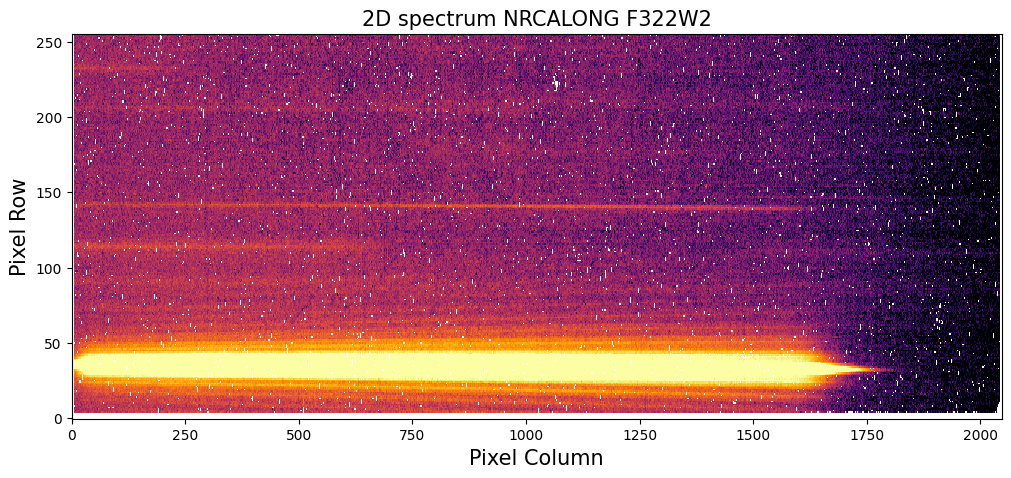

In [45]:
if do_viz:
    # Load data
    ramp_HDUL = datamodels.open(rateints_files_lw[0])
    ramp_sci = ramp_HDUL.data
    detector = ramp_HDUL.meta.instrument.detector.upper()
    filtname = ramp_HDUL.meta.instrument.filter.upper()

    # Select an integration
    int_id = -1

    # Get min and max for scaling and normalize
    vmin, vmax = np.nanpercentile(ramp_sci[int_id, :, :], [5, 95])
    norm = ImageNormalize(ramp_sci[int_id, :, :],
                          vmin=vmin,
                          vmax=vmax,
                          stretch=AsinhStretch(a=0.05)
                          )

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))

    im = ax.imshow(ramp_sci[int_id, :, :],
                   interpolation="None",
                   aspect="auto",
                   cmap="inferno",
                   origin="lower",
                   norm=norm
                   )

    _ = ax.set_title(f"2D spectrum {detector} {filtname}", fontsize=15)
    _ = ax.set_xlabel("Pixel Column", fontsize=15)
    _ = ax.set_ylabel("Pixel Row", fontsize=15)
    plt.savefig(os.path.join(det1_dir, "nrc_gts_rateints.png"), dpi=150)
    plt.show()

The source spectrum is the bright horizontal trace centered at about y = 34. There are some faint horizontal stripes visible in other locations within the image. These could potentially [originate from neighboring sources](https://jwst-docs.stsci.edu/jwst-near-infrared-camera/nircam-observing-strategies/nircam-time-series-observation-recommended-strategies#NIRCamTimeSeriesObservationRecommendedStrategies-Spectroscopicandimageoverlap). To avoid contamination while extracting the source spectrum, users can adjust the extract 1D reference file as needed, and as was done in the sections above.

### 8.2 Display `Spec2Pipeline` Products

Inspect Stage 2 calibrated spectra by displaying the 2D extracted spectrum, and then plotting three one-dimensional spectra from the spectral time series with a constant offset for clarity.<br>

First, load one integration from one of the calints files and scale it such that we get a good view of the center of the trace. This is the 2D array on which the extract1D step of the pipeline operates. The coordinates in the extract1D reference file described in [Section 6.1](#6.1-Configure-Spec2Pipeline) are in the coordinate system of this 2D array. Noting the x and y locations of the trace, as well as areas suitable for calculating the background, users can tailor their extract1D reference file if the default reference file does not give optimal results.

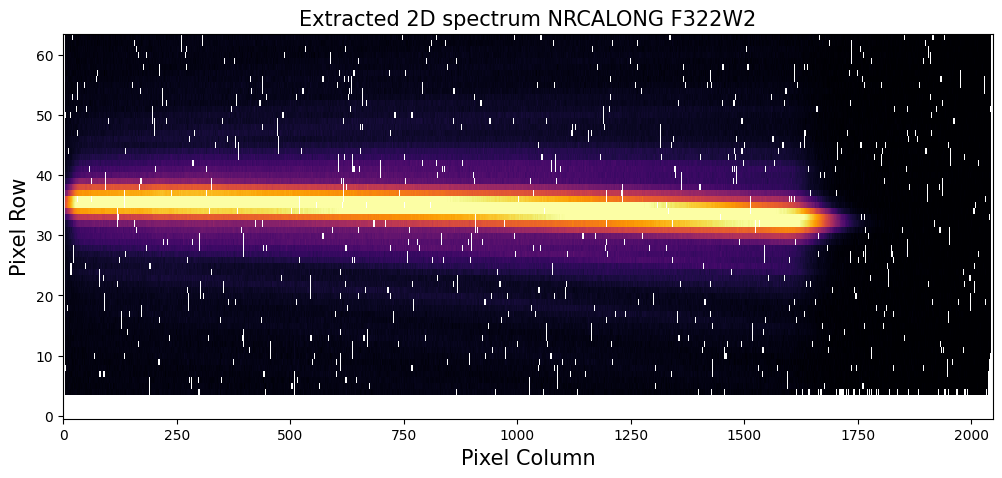

In [46]:
if do_viz:
    # Load data
    cal_HDUL = datamodels.open(calints_files[0])
    calints = cal_HDUL.data
    detector = cal_HDUL.meta.instrument.detector.upper()
    filtname = cal_HDUL.meta.instrument.filter.upper()

    # Select an integration
    int_id = -1

    # Get min and max for scaling and normalize
    vmin, vmax = np.nanpercentile(calints[int_id, :, :], [3, 97])
    norm = ImageNormalize(calints[int_id, :, :],
                          vmin=vmin,
                          vmax=vmax,
                          stretch=AsinhStretch(a=0.05)
                          )

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, 5))

    im = ax.imshow(calints[int_id, :, :],
                   interpolation="None",
                   aspect="auto",
                   cmap="inferno",
                   origin="lower",
                   norm=norm
                   )

    _ = ax.set_title(f"Extracted 2D spectrum {detector} {filtname}", fontsize=15)
    _ = ax.set_xlabel("Pixel Column", fontsize=15)
    _ = ax.set_ylabel("Pixel Row", fontsize=15)
    plt.savefig(os.path.join(det1_dir, "nrc_gts_calints.png"), dpi=150)
    plt.show()

Next, look at the 1D extracted spectra from the Spec2 pipeline. To make that easier, first consolidate all extracted spectra (from each segment) and their corresponding timestamps into single large arrays.

In [47]:
x1d = datamodels.open(sci_x1d[0])

#x1d.info(max_rows=None) # prints the full contents
x1d.info(max_rows=10)
#print(x1d)

# Obtain the wavelength and flux from 1d spectral products
x1d_wave = x1d.spec[0].spec_table.WAVELENGTH
x1d_flux = x1d.spec[0].spec_table.FLUX

# Get flux unit from FITS header of _x1dints.fits
flux_unit = x1d.spec[0].spec_table.columns['FLUX'].unit


wave_um = x1d_wave
all_times = x1d.int_times.int_mid_BJD_TDB

n_spec = len(x1d.spec)
n_pix = len(x1d.spec[0].spec_table.FLUX)

root (AsdfObject)
├─asdf_library (Software) ...
├─history (dict)
│ └─extensions (list) ...
├─_fits_hash (str): 0f4c76e40cd3b1d308b6e47e3d3e109f191905da89130f9ed7d45ec478b3f626
├─cal_logs (dict) ...
├─int_times (FITS_rec)
├─meta (dict) ...
└─spec (list) ...
Some nodes not shown.


In [48]:
# Obtain all spectra for the list of segments
for i in range(len(sci_x1d)):
    print("Processing segment: ", i+1, ' out of ', len(sci_x1d), ': ', sci_x1d[i])
    x1d = datamodels.open(sci_x1d[i])

    seg_spec_1D = np.vstack([spec.spec_table['FLUX'] for spec in x1d.spec])

    if i == 0:
        all_spec_1D = seg_spec_1D
        all_times = x1d.int_times.int_mid_BJD_TDB
        wave_um = x1d.spec[0].spec_table['WAVELENGTH'][0]
    else:
        all_spec_1D = np.concatenate((all_spec_1D, seg_spec_1D), axis=0)
        all_times = np.concatenate((all_times, x1d.int_times.int_mid_BJD_TDB), axis=0)

    x1d.close()

print(' ')
print('Total number of time stamps: ', len(all_times))
print('Total number of 1D spectra:  ', all_spec_1D.shape[0])
print(' ')
print('Total number of columns: ', all_spec_1D.shape[1])
print('Total length of wavemap: ', len(wave_um))

Processing segment:  1  out of  4 :  ./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg001_nrcalong_x1dints.fits
Processing segment:  2  out of  4 :  ./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg002_nrcalong_x1dints.fits
Processing segment:  3  out of  4 :  ./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg003_nrcalong_x1dints.fits


Processing segment:  4  out of  4 :  ./nrc_tso_demo_data/01366/Obs002/stage2/jw01366002001_04103_00001-seg004_nrcalong_x1dints.fits
 
Total number of time stamps:  366
Total number of 1D spectra:   366
 
Total number of columns:  1701
Total length of wavemap:  1701


Now plot some examples of extracted 1D spectra, from the x1dints files generated by the Spec2 pipeline. Plot the extracted spectra from integrations 0, 10, and 100, with vertical offsets between them for clarity.

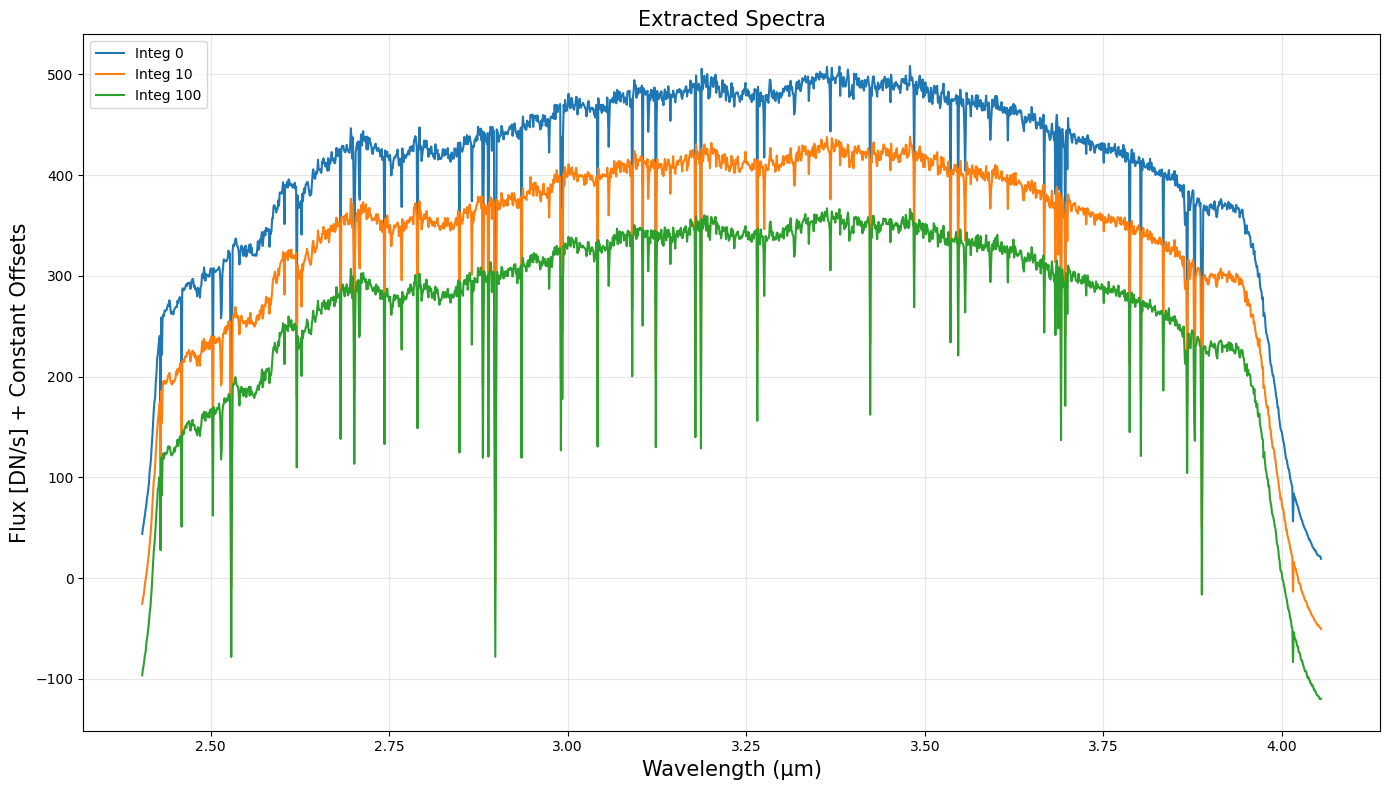

In [49]:
# Plot three spectra from the time series with a constant offset for clarity
if do_viz:
    fig, ax = plt.subplots(figsize=(14, 8))
    _ = ax.plot(wave_um, all_spec_1D[0, :]-0.0, label='Integ 0')
    _ = ax.plot(wave_um, all_spec_1D[10, :]-70.0, label='Integ 10')
    _ = ax.plot(wave_um, all_spec_1D[100, :]-140.0, label='Integ 100')

    _ = ax.set_title("Extracted Spectra", fontsize=15)
    _ = ax.set_xlabel("Wavelength (μm)", fontsize=15)
    _ = ax.set_ylabel(f"Flux [{flux_unit}] + Constant Offsets", fontsize=15)
    ax.grid(True, alpha=0.3)
    _ = ax.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(spec2_dir, "nrc_gts_extracted_spectra.png"), dpi=150)
    plt.show()

Let's create a white light curve from the 1D spectra output by the Spec2 pipeline. Note that a final white light curve is created by the TSO3 pipeline, as shown in the [Display Tso3Pipeline Products](#8.3-Display-Tso3Pipeline-Products) section below. This version, created from the Spec2 x1dints files, can be used as a quick quality check.

Create and plot the extracted white light photometric light curve by summing the flux from the wavelength range of each extracted one-dimensional spectrum. Normalize the light curve by dividing the light curve flux to the median flux of the first twenty data points. Calculate and report the scatter using the first ~100 data points.

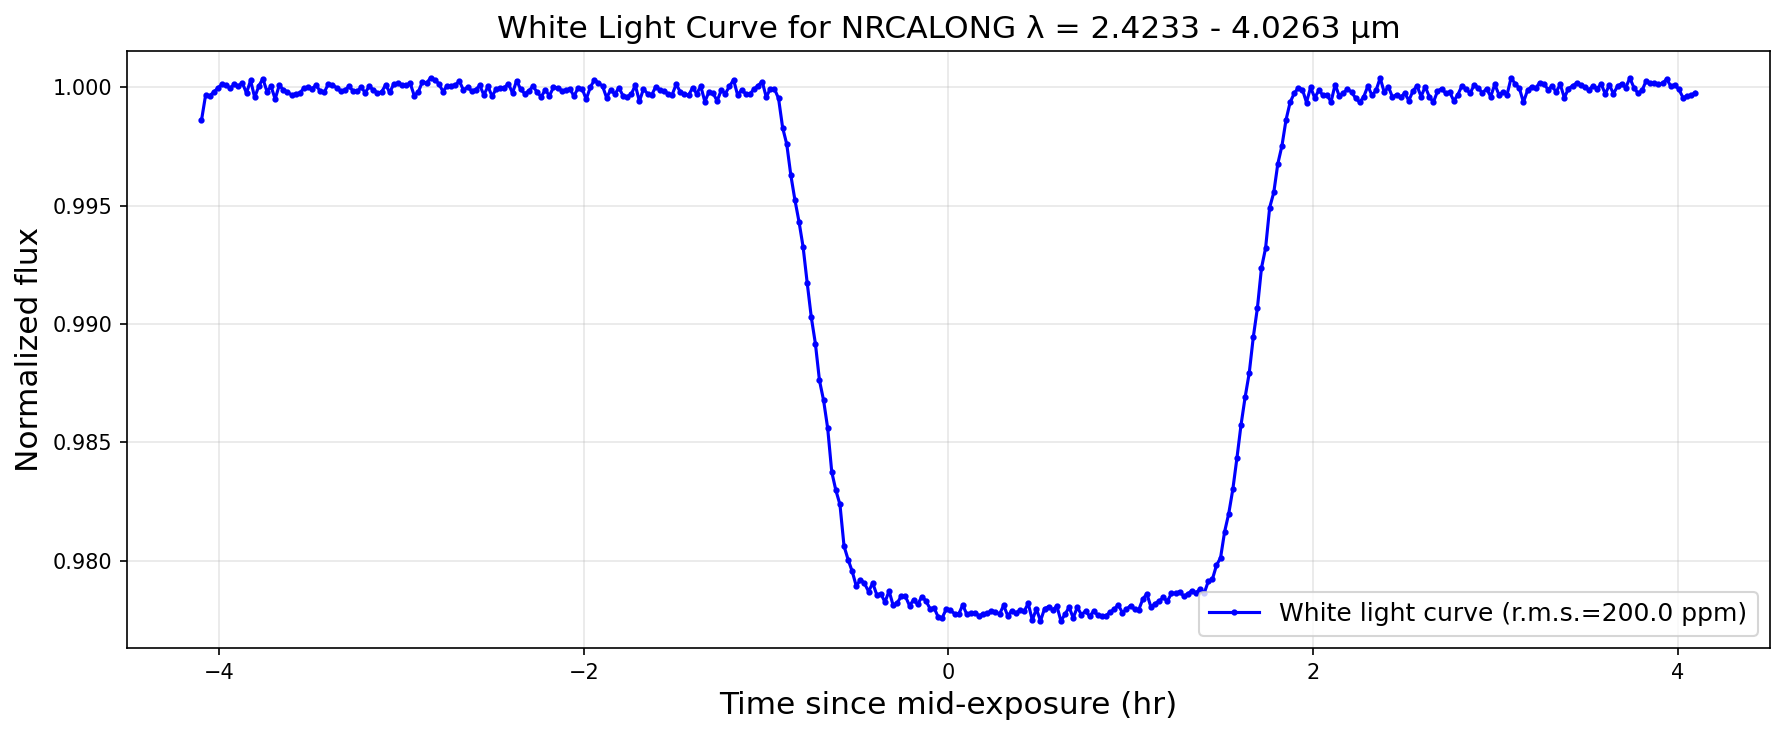

In [50]:
if do_viz:
    n_spec = len(all_times)

    # Obtain white light curve
    wlc_flux = np.zeros(n_spec)

    # Sum of flux to calculate the white light curve
    total_flux_cols = (20, -30)
    col_start, col_end = total_flux_cols
    for i in range(n_spec):
        wlc_flux[i] = np.nansum(all_spec_1D[i, col_start:col_end])

    # Normalize by the median flux of the first twenty points
    wlc_flux /= np.median(wlc_flux[0:20])

    # Calculate light curve scatter from first ~100 points
    wlc_flux_s = sigma_clip(wlc_flux, sigma=1, maxiters=2, masked=False)
    sigma_wlc = np.sqrt(np.nanvar(wlc_flux_s[2:100]))
    sigma_wlc_ppm = round(sigma_wlc * 1e6, 0)
    time_axis = (all_times - np.nanmean(all_times)) * 24.0
    wavestart = round(wave_um[col_start], 4)
    waveend = round(wave_um[col_end], 4)

    fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
    _ = ax.plot(
                time_axis,
                wlc_flux,
                color='blue',
                marker="o",
                markersize=2,
                label=f"White light curve (r.m.s.={sigma_wlc_ppm} ppm)"
                )

    _ = ax.set_title(f"White Light Curve for {detector} λ = {wavestart} - {waveend} μm", fontsize=15)
    _ = ax.set_xlabel("Time since mid-exposure (hr)", fontsize=15)
    _ = ax.set_ylabel("Normalized flux", fontsize=15)
    _ = ax.legend(loc='lower right', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(spec2_dir, "nrc_gts_whitelight.png"), dpi=150)
    plt.show()

### 8.3 Display `Tso3Pipeline` Products

Read in and plot the white light curve output by the Tso3Pipeline. This can be compared to the manually-created white light plot above.

sigma in ppm:  199.36866961626987


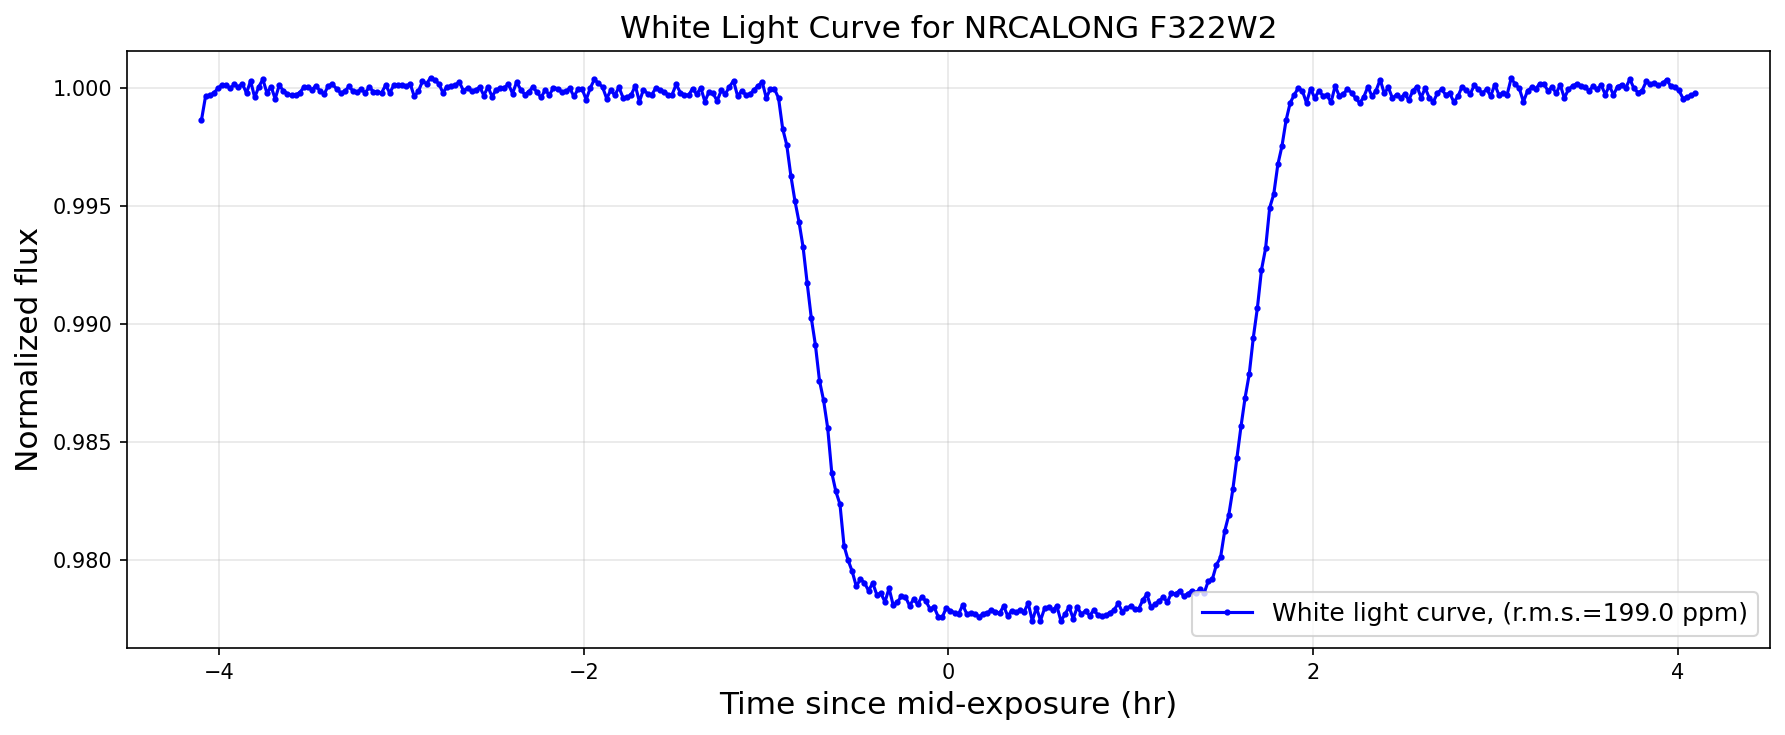

In [51]:
if do_viz:
    data = pd.read_csv(stage3_whtlt[0], comment="#", delimiter=" ")
    time_BJD = data['BJD_TDB']
    wht = data['whitelight_flux']
    wht = wht/np.median(wht[0:20])
    print('sigma in ppm: ', np.std(wht[2:100])*1e6)

    # Calculate light curve scatter from first ~100 points.
    sigma_wlc = np.sqrt(np.nanvar(wht[2:100]))
    sigma_wlc_ppm = round(sigma_wlc * 1e6, 0)

    # Plot light curve
    fig, ax = plt.subplots(figsize=(12, 5), dpi=150)
    _ = ax.plot((time_BJD-np.nanmean(time_BJD))*24., wht, color='blue', marker="o", markersize=2,
                label=f'White light curve, (r.m.s.={sigma_wlc_ppm} ppm)')
    _ = ax.set_title(f'White Light Curve for {detector} {filtname}', fontsize=15)
    _ = ax.set_xlabel('Time since mid-exposure (hr)', fontsize=15)
    _ = ax.set_ylabel('Normalized flux', fontsize=15)
    _ = ax.legend(loc='lower right', fontsize=12)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(tso3_dir, 'nrc_gts_tso3_wlc.png'), dpi=150)
    plt.show()

Finally, plot the spectroscopic light curves contained in the *x1dints.fits file. 

The 2D map below shows all extracted, normalized 1D spectra spanning the full observation. The horizontal axis is the spectral direction in wavelength ($\mu m$), and the vertical axis represents each integration in time (bottom = first integration, top = last). Each column is normalized by the median flux of the first {n_baseline} out-of-transit integrations, so values near 1.0 (darker tones in the colorbar) indicate flux consistent with stellar baseline, while values below 1.0 (lighter tones) indicate flux suppression due to the planetary transit. The transit is visible as a horizontal band of decreased normalized flux spanning the in-transit integrations across all wavelengths. Ingress and egress appear as gradual transitions at the upper and lower boundaries of this band. Reduced sensitivity near the edges of the bandpass is visible as increased scatter at the spectral extremes, consistent with lower instrument throughput of the filter at those wavelengths.

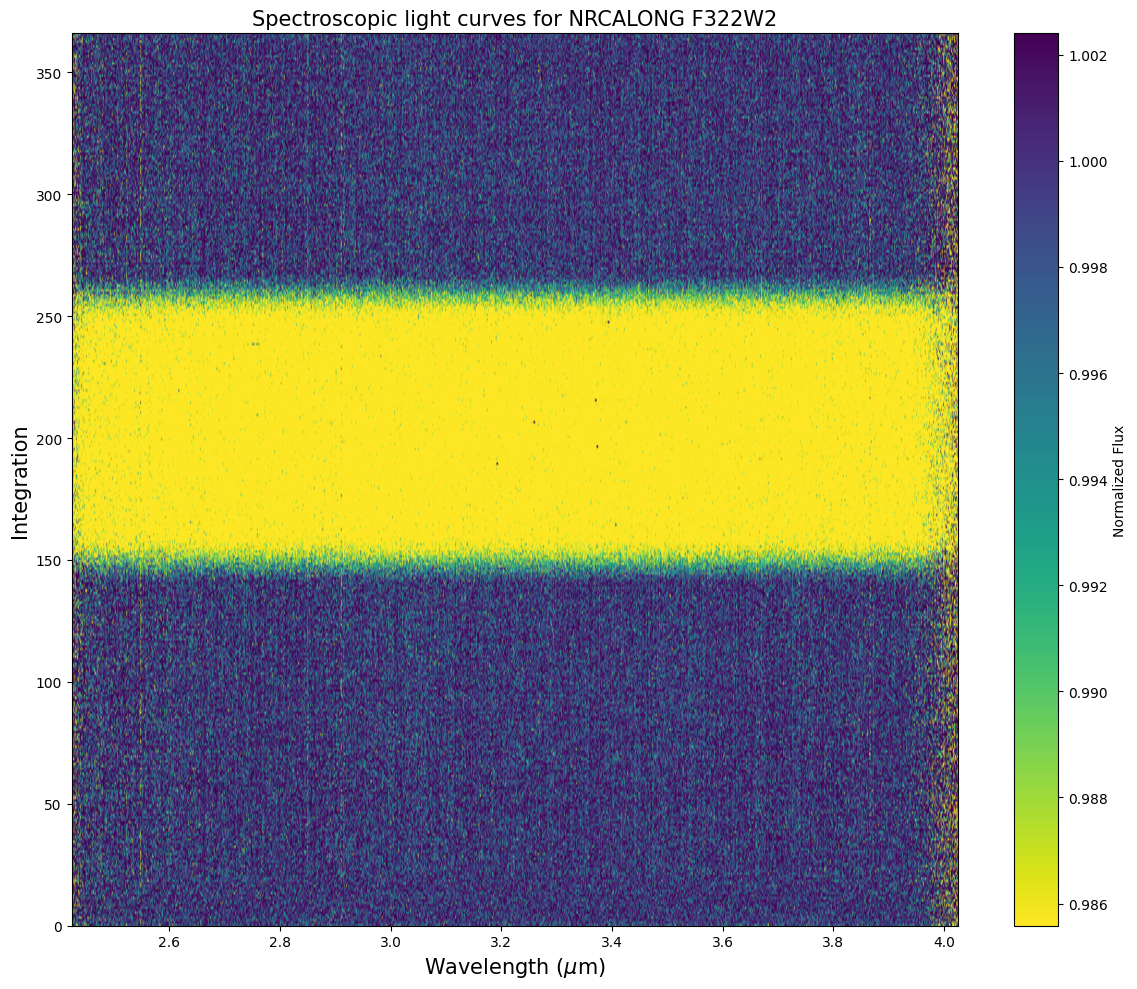

In [52]:
lc_map = np.copy(all_spec_1D)

spec_xlen = len(lc_map[0, :])

# Define out-of-transit baseline
n_baseline = 20
for j in range(spec_xlen):
    # Normalize each spectrum by the mean
    lc_map[:, j] /= np.nanmean(lc_map[0:n_baseline, j])

slc_sigma = 3
lc_std = np.nanstd(lc_map[0:n_baseline, :])
vmin = 1.0 - slc_sigma * lc_std
vmax = 1.0 + 0.5 * lc_std

fig, ax = plt.subplots(figsize=(12, 10))
_ = ax.set_title(
                 f"Spectroscopic light curves for {detector} {filtname}",
                 fontsize=15
                 )
im1 = ax.imshow(
    lc_map,
    interpolation="bilinear",
    aspect="auto",
    cmap="viridis_r",
    origin="lower",
    clim=(vmin, vmax),
    extent=[wavestart, waveend, 0, lc_map.shape[0]]
)

_ = ax.set_xlabel(r"Wavelength ($\mu$m)", fontsize=15)
_ = ax.set_ylabel("Integration", fontsize=15)

cb1 = fig.colorbar(im1, ax=ax, label=r"Normalized Flux")
plt.tight_layout()
plt.savefig(os.path.join(tso3_dir, 'nrc_gts_speclc_map.png'), dpi=150, bbox_inches='tight')
plt.show()

<hr style="border:1px solid gray"> </hr>

<img style="float: center;" src="https://github.com/spacetelescope/jwst-pipeline-notebooks/raw/main/_static/stsci_footer.png" alt="stsci_logo" width="200px"/> 

[Top of Page](#NIRCam-Grism-Time-Series-Pipeline-Notebook)